# Lecture 5 — Class Exercise
## Distribution Charts: Airbnb London

> **Push to:** `week05/lecture05_exercise.ipynb`

**Rules:**
1. Cap price outliers at 95th percentile — annotate this
2. Every chart has a **median/mean reference line** with annotation
3. Insight title names the distribution shape or key finding
4. Colour has meaning — don't use colour just for decoration

---


In [4]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Airbnb London Listings

df = pd.read_csv('../data/airbnb_london.csv')
print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))


Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


In [5]:
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]
print(f"95th percentile price: £{p95:.0f}")
print(df_cap.groupby('room_type')['price'].describe().round(1))


95th percentile price: £373
                  count   mean   std   min    25%    50%    75%    max
room_type                                                             
Entire home/apt  1251.0  176.3  75.7  28.0  119.6  163.4  223.5  372.6
Private room      942.0   87.3  39.5  20.9   59.0   78.6  106.0  277.9
Shared room       182.0   46.3  14.1  20.5   36.8   44.1   54.3   92.8


## Task 1 — Histogram: price by room type (overlapping distributions)

**What to build:** A histogram showing price distributions for **Entire home/apt vs Private room** (exclude Shared room — too few observations) overlaid on the same chart.

**Requirements:**
- Both room types on the same chart (use `color='room_type'`)
- `barmode='overlay'` with `opacity=0.6` so both distributions are visible
- A vertical line for the median of EACH room type, differently coloured
- Insight title comparing the two distributions

> 💡 `df_cap[df_cap['room_type'].isin(['Entire home/apt','Private room'])]`


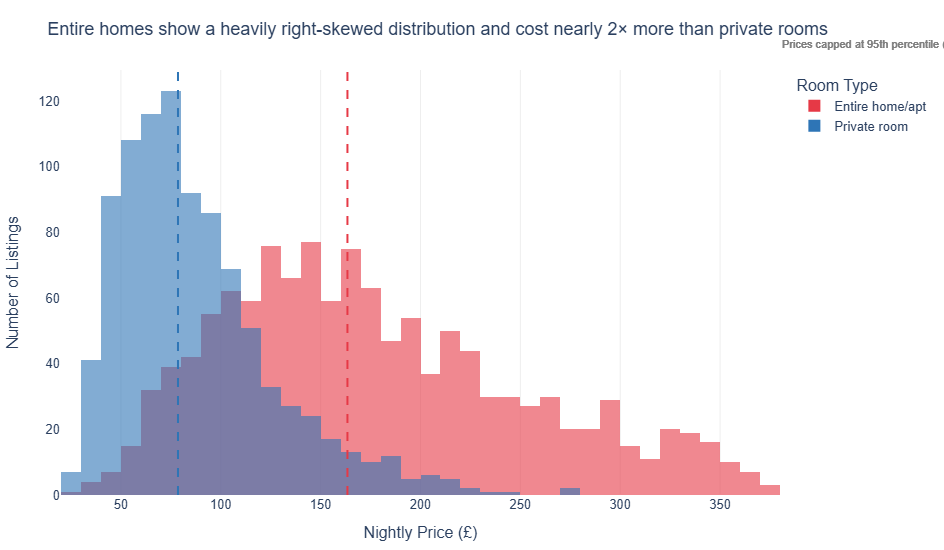

In [6]:
# Task 1
# YOUR CODE HERE
# =========================================================
# Task 1 — Histogram: price by room type
# =========================================================

# Filter only Entire home/apt and Private room
df_hist = df_cap[df_cap['room_type'].isin(['Entire home/apt', 'Private room'])]

# Median prices
median_entire = df_hist[df_hist['room_type'] == 'Entire home/apt']['price'].median()
median_private = df_hist[df_hist['room_type'] == 'Private room']['price'].median()

# Histogram
fig = px.histogram(
    df_hist,
    x='price',
    color='room_type',
    nbins=50,
    barmode='overlay',
    opacity=0.6,
    color_discrete_map={
        'Entire home/apt': '#E63946',
        'Private room': '#2E75B6'
    },
    labels={
        'price': 'Nightly Price (£)',
        'room_type': 'Room Type'
    },
    height=550
)

# Median line — Entire home
fig.add_vline(
    x=median_entire,
    line_dash='dash',
    line_color='#E63946',
    line_width=2,
    annotation=dict(
        text=f'Entire home median: £{median_entire:.0f}',
        font=dict(color='#E63946', size=11),
        xanchor='left'
    )
)

# Median line — Private room
fig.add_vline(
    x=median_private,
    line_dash='dash',
    line_color='#2E75B6',
    line_width=2,
    annotation=dict(
        text=f'Private room median: £{median_private:.0f}',
        font=dict(color='#2E75B6', size=11),
        xanchor='left'
    )
)

# Layout improvements
fig.update_layout(
    title='Entire homes show a heavily right-skewed distribution and cost nearly 2× more than private rooms',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    xaxis=dict(
        title='Nightly Price (£)',
        gridcolor='#EEEEEE'
    ),
    yaxis=dict(
        title='Number of Listings',
        showgrid=False
    ),
    margin=dict(l=60, r=40, t=70, b=40),
    annotations=[
        dict(
            text=f'Prices capped at 95th percentile (£{p95:.0f}) to improve readability',
            xref='paper',
            yref='paper',
            x=1,
            y=1.08,
            showarrow=False,
            font=dict(size=11, color='gray')
        )
    ]
)

fig.show()

## Task 2 — Box plot: listing activity by borough

**What to build:** A **horizontal box plot** comparing listing activity (reviews per month) across London boroughs — reviews per month is a proxy for how frequently a listing is booked.

**Requirements:**
- Horizontal orientation (borough names are long)
- Sorted by median reviews per month (most active at top)
- Highlight the **two most active** boroughs in a different colour
- Outliers shown as individual points
- Insight title naming the two busiest boroughs

> 💡 Some listings have zero reviews — these are new or inactive listings. Filter them out with before plotting

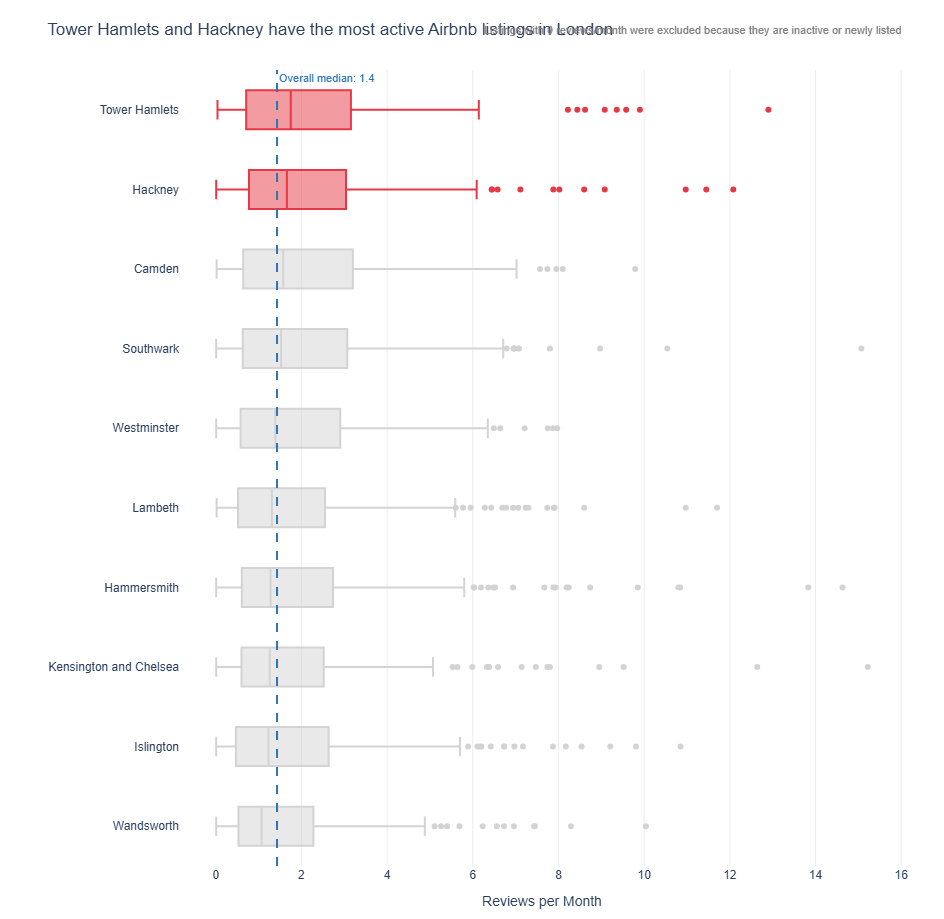

In [8]:
# Task 2
# YOUR CODE HERE
# =========================================================
# Task 2 — Box plot: listing activity by borough
# =========================================================

# Remove listings with zero reviews per month
df_reviews = df[df['reviews_per_month'] > 0].copy()

# Sort boroughs by median reviews per month
borough_order = (
    df_reviews.groupby('neighbourhood')['reviews_per_month']
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

# Top 2 busiest boroughs
top2 = borough_order[:2]

# Create colour map
color_map = {}

for borough in borough_order:
    if borough in top2:
        color_map[borough] = '#E63946'   # highlight busiest
    else:
        color_map[borough] = '#D3D3D3'   # grey for others

# Box plot
fig = px.box(
    df_reviews,
    y='neighbourhood',
    x='reviews_per_month',
    color='neighbourhood',
    orientation='h',
    points='outliers',
    category_orders={'neighbourhood': borough_order},
    color_discrete_map=color_map,
    labels={
        'reviews_per_month': 'Reviews per Month',
        'neighbourhood': ''
    },
    height=900,
    width=1000
)

# Add overall median reference line
overall_median = df_reviews['reviews_per_month'].median()

fig.add_vline(
    x=overall_median,
    line_dash='dash',
    line_color='#2E75B6',
    line_width=2,
    annotation=dict(
        text=f'Overall median: {overall_median:.1f}',
        font=dict(color='#2E75B6', size=11),
        xanchor='left'
    )
)

# Layout improvements
fig.update_layout(
    title=f'{top2[0]} and {top2[1]} have the most active Airbnb listings in London',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    xaxis=dict(
        title='Reviews per Month',
        gridcolor='#EEEEEE'
    ),
    yaxis=dict(showgrid=False),
    showlegend=False,
    margin=dict(l=180, r=40, t=70, b=40)
)

# Annotation
fig.add_annotation(
    text='Listings with 0 reviews/month were excluded because they are inactive or newly listed',
    xref='paper',
    yref='paper',
    x=1,
    y=1.06,
    showarrow=False,
    font=dict(size=11, color='gray')
)

fig.show()
